# Simple L2 Modle
とりあえず外政変数を入れてみただけのモデルを作成
$$
\log{S_t} = \gamma + \alpha \log{S_{t-1}} + \beta ( T_{t-1} - \bar{T}_{t-1} )^2  + \eta_t
$$

In [ ]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside paper_study.")
PROJECT_DIR = (
    REPO_ROOT
    / "One_week_ahead_electricity_price_forecasting_using_weather_forecasts_and_its_application_to_arbitrage_in_the_forward_market_an_empirical_study_of_the_JEPX"
)
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn
import statsmodels
import seaborn

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib", matplotlib.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("statsmodels:", statsmodels.__version__)
print("seaborn:", seaborn.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib 3.10.8
scipy: 1.17.1
sklearn: 1.8.0
statsmodels: 0.14.6
seaborn: 0.13.2


In [2]:
weekly_base = pd.read_csv((PROJECT_DATA_DIR / "processed/weekly_base_after_2017.csv"))
weekly_base["datetime"] = pd.to_datetime(weekly_base["datetime"])

weekly_base = weekly_base.set_index("datetime")
weekly_base = weekly_base.asfreq("W")

weekly_base.head()

,tokyo_price,temp,tmin,tmax,temp_mean_past,temp_centered,temp_centered_sq,temp_diff
datetime,,,,,,,,
2017-04-02,10.502321,8.528571,4.528571,12.857143,16.266307,-7.737736,59.872556,-0.385714
2017-04-09,10.566220,14.214286,10.514286,18.342857,16.228307,-2.014021,4.056281,5.685714
2017-04-16,10.523185,14.257143,9.328571,19.357143,16.192468,-1.935325,3.745482,0.042857
2017-04-23,9.521696,16.314286,12.271429,22.071429,16.194643,0.119643,0.014314,2.057143
2017-04-30,8.624762,16.157143,11.828571,21.057143,16.193985,-0.036842,0.001357,-0.157143


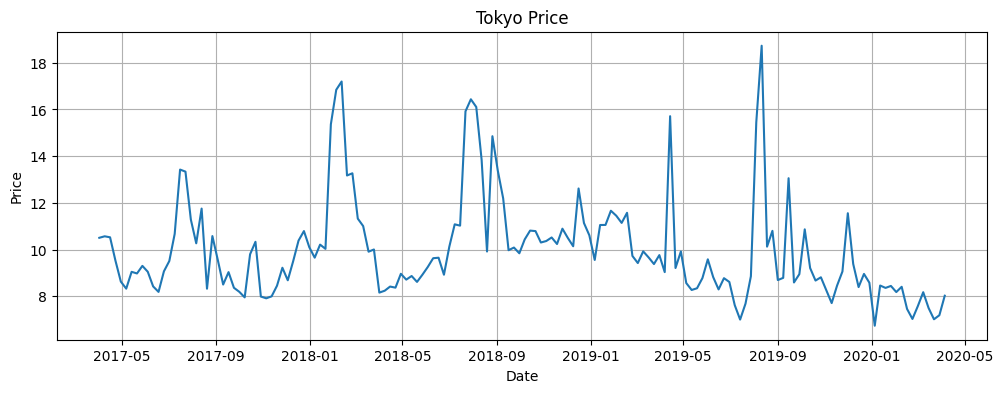

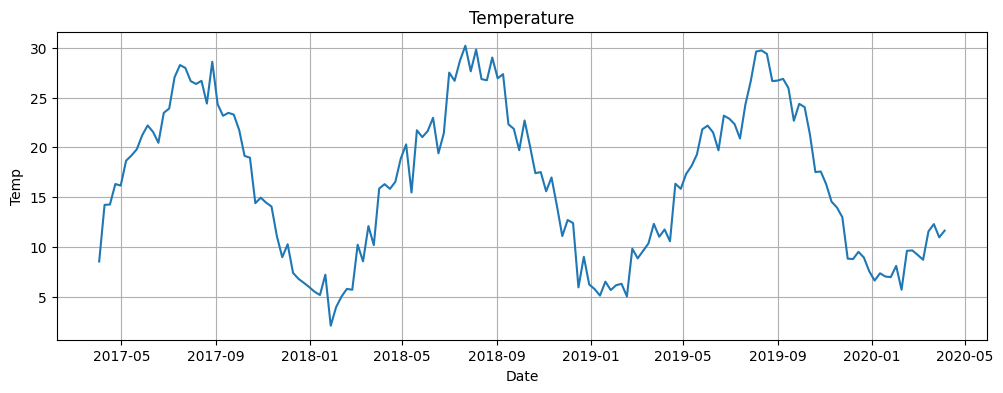

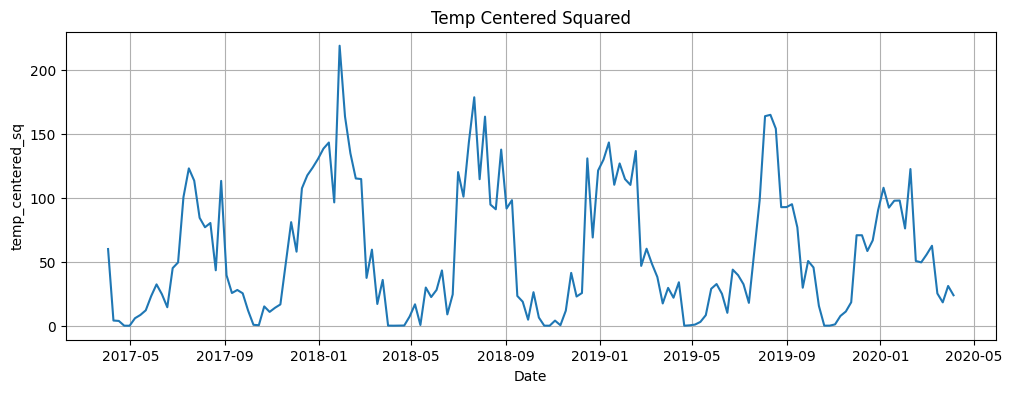

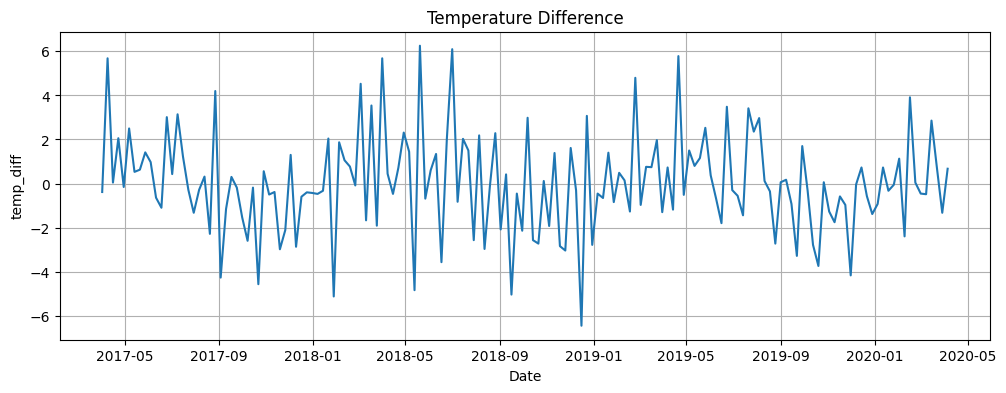

In [3]:
import matplotlib.pyplot as plt

# 1. tokyo_price
plt.figure(figsize=(12, 4))

plt.plot(weekly_base.index, weekly_base["tokyo_price"])

plt.title("Tokyo Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.grid(True)

plt.show()


# 2. temp
plt.figure(figsize=(12, 4))

plt.plot(weekly_base.index, weekly_base["temp"])

plt.title("Temperature")
plt.xlabel("Date")
plt.ylabel("Temp")

plt.grid(True)

plt.show()


# 3. temp_centered_sq
plt.figure(figsize=(12, 4))

plt.plot(weekly_base.index, weekly_base["temp_centered_sq"])

plt.title("Temp Centered Squared")
plt.xlabel("Date")
plt.ylabel("temp_centered_sq")

plt.grid(True)

plt.show()


# 4. temp_diff
plt.figure(figsize=(12, 4))

plt.plot(weekly_base.index, weekly_base["temp_diff"])

plt.title("Temperature Difference")
plt.xlabel("Date")
plt.ylabel("temp_diff")

plt.grid(True)

plt.show()

# 生成モデルはどのくらいそれっぽいか？

In [4]:
from scipy.optimize import minimize
# =============================
# 前処理
# =============================

df = weekly_base.copy()
df = df.sort_index()

# 念のため
df["log_price"] = np.log(df["tokyo_price"])

# ラグ変数
df["log_price_lag1"] = df["log_price"].shift(1)
df["temp_centered_sq_lag1"] = df["temp_centered_sq"].shift(1)
df["temp_diff_lag1"] = df["temp_diff"].shift(1)

df = df.dropna()

In [5]:
df.head()

,tokyo_price,temp,tmin,tmax,temp_mean_past,temp_centered,temp_centered_sq,temp_diff,log_price,log_price_lag1,temp_centered_sq_lag1,temp_diff_lag1
datetime,,,,,,,,,,,,
2017-04-09,10.566220,14.214286,10.514286,18.342857,16.228307,-2.014021,4.056281,5.685714,2.357662,2.351596,59.872556,-0.385714
2017-04-16,10.523185,14.257143,9.328571,19.357143,16.192468,-1.935325,3.745482,0.042857,2.353581,2.357662,4.056281,5.685714
2017-04-23,9.521696,16.314286,12.271429,22.071429,16.194643,0.119643,0.014314,2.057143,2.253573,2.353581,3.745482,0.042857
2017-04-30,8.624762,16.157143,11.828571,21.057143,16.193985,-0.036842,0.001357,-0.157143,2.154637,2.253573,0.014314,2.057143
2017-05-07,8.323155,18.657143,14.228571,24.428571,16.236453,2.420690,5.859738,2.500000,2.119041,2.154637,0.001357,-0.157143


In [6]:
# =============================
# 学習・テスト分割
# 2017年度・2018年度で推定
# 2019年度でシミュレーション比較
# =============================

train = df.loc["2017-04-01":"2019-03-31"].copy()
test = df.loc["2019-04-01":"2020-03-31"].copy()

print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

2017-04-09 00:00:00 2019-03-31 00:00:00
2019-04-07 00:00:00 2020-03-29 00:00:00


$$
\log{S_t} = \alpha \log{S_{t-1}} + \beta ( T_{t-1} - \bar{T}_{t-1} )^2  + \eta_t
$$

In [7]:
# =============================
# モデル1：負の対数尤度
# =============================


def neg_log_likelihood_model1(params, data):
    alpha, beta, log_sigma = params
    sigma = np.exp(log_sigma)

    y = data["log_price"].values
    x1 = data["log_price_lag1"].values
    x2 = data["temp_centered_sq_lag1"].values

    mu = alpha * x1 + beta * x2
    resid = y - mu

    nll = 0.5 * np.sum(np.log(2 * np.pi * sigma**2) + (resid**2) / sigma**2)
    return nll

In [8]:
# =============================
# 初期パラメータをデータから作る
# =============================

# alpha:
# log価格のラグ1自己相関を利用
alpha_init = train["log_price"].autocorr(lag=1)

# beta:
# 小さめで開始
beta_init = 0.001

# sigma:
# log価格の標準偏差を利用
sigma_init = train["log_price"].std()

init_params = np.array([alpha_init, beta_init, np.log(sigma_init)])

print(init_params)

[ 7.57551799e-01  1.00000000e-03 -1.73009325e+00]


In [9]:
# =============================
# モデル1：MLE
# =============================

# init_params = np.array([0.9, 0.001, np.log(0.1)])

result1 = minimize(
    neg_log_likelihood_model1, init_params, args=(train,), method="Nelder-Mead"
)

alpha1, beta1, log_sigma1 = result1.x
sigma1 = np.exp(log_sigma1)

print("Model 1")
print("alpha =", alpha1)
print("beta  =", beta1)
print("sigma =", sigma1)
print("success =", result1.success)

Model 1
alpha = 0.9994452259091171
beta  = -4.2157585600767805e-05
sigma = 0.12273296769313446
success = True


In [10]:
# =============================
# モデル1：2019年度を100本シミュレーション
# =============================


def simulate_model1(test, alpha, beta, sigma, n_sim=100, seed=42):
    rng = np.random.default_rng(seed)

    sims = pd.DataFrame(index=test.index)

    for i in range(n_sim):
        log_s = []
        log_prev = test["log_price"].iloc[0]  # 初期値だけ実データを使用

        for t in range(len(test)):
            x_temp = test["temp_centered_sq_lag1"].iloc[t]
            eps = rng.normal(0, sigma)

            log_new = alpha * log_prev + beta * x_temp + eps
            log_s.append(log_new)

            log_prev = log_new

        sims[f"sim_{i + 1}"] = np.exp(log_s)

    return sims


sims1 = simulate_model1(test, alpha1, beta1, sigma1, n_sim=100)

In [11]:
# =============================
# MSE順位でパスを分類
# =============================

actual = test["tokyo_price"]

mse_by_path = ((sims1.sub(actual, axis=0)) ** 2).mean(axis=0)
mse_sorted = mse_by_path.sort_values()

# 近いパス3本
near_paths = mse_sorted.index[:3]

# 中間パス3本
mid = len(mse_sorted) // 2
middle_paths = mse_sorted.index[mid - 1 : mid + 2]

# だめだめパス3本
bad_paths = mse_sorted.index[-3:]

print("Near paths")
print(mse_sorted.loc[near_paths])

print("\nMiddle paths")
print(mse_sorted.loc[middle_paths])

print("\nBad paths")
print(mse_sorted.loc[bad_paths])

Near paths
sim_27    5.419656
sim_63    5.916355
sim_98    7.375681
dtype: float64

Middle paths
sim_93    21.237964
sim_85    21.339674
sim_23    21.466703
dtype: float64

Bad paths
sim_49     276.076139
sim_58     355.922438
sim_82    1045.071831
dtype: float64


In [12]:
# =============================
# プロット用関数
# =============================


def plot_selected_paths(sims, test, paths, title):
    plt.figure(figsize=(14, 6))

    for col in paths:
        plt.plot(
            sims.index,
            sims[col],
            linewidth=2,
            label=f"{col}, MSE={mse_by_path[col]:.2f}",
        )

    plt.plot(
        test.index, test["tokyo_price"], color="black", linewidth=3, label="Actual 2019"
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Tokyo price")
    plt.legend()
    plt.grid(True)
    plt.show()

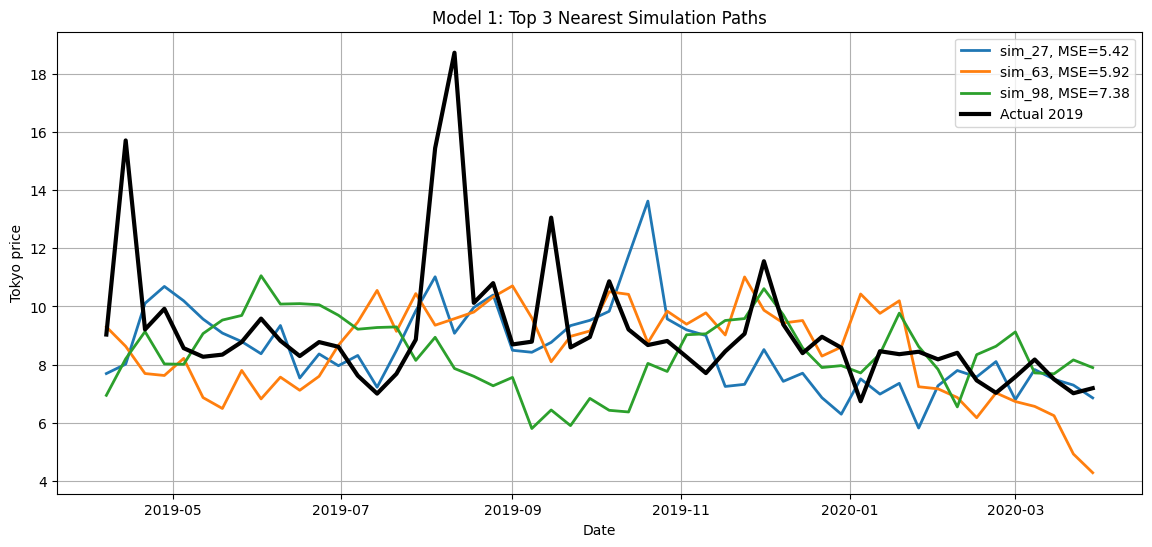

In [13]:
# =============================
# 近いパス3本
# =============================

plot_selected_paths(
    sims=sims1,
    test=test,
    paths=near_paths,
    title="Model 1: Top 3 Nearest Simulation Paths",
)

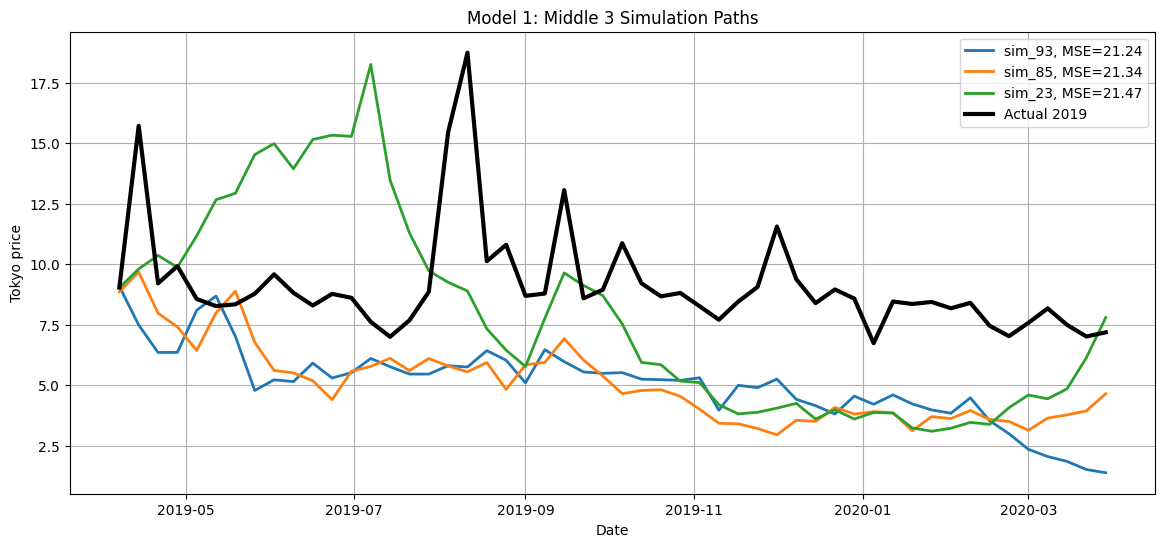

In [14]:
# =============================
# 中間パス3本
# =============================

plot_selected_paths(
    sims=sims1,
    test=test,
    paths=middle_paths,
    title="Model 1: Middle 3 Simulation Paths",
)

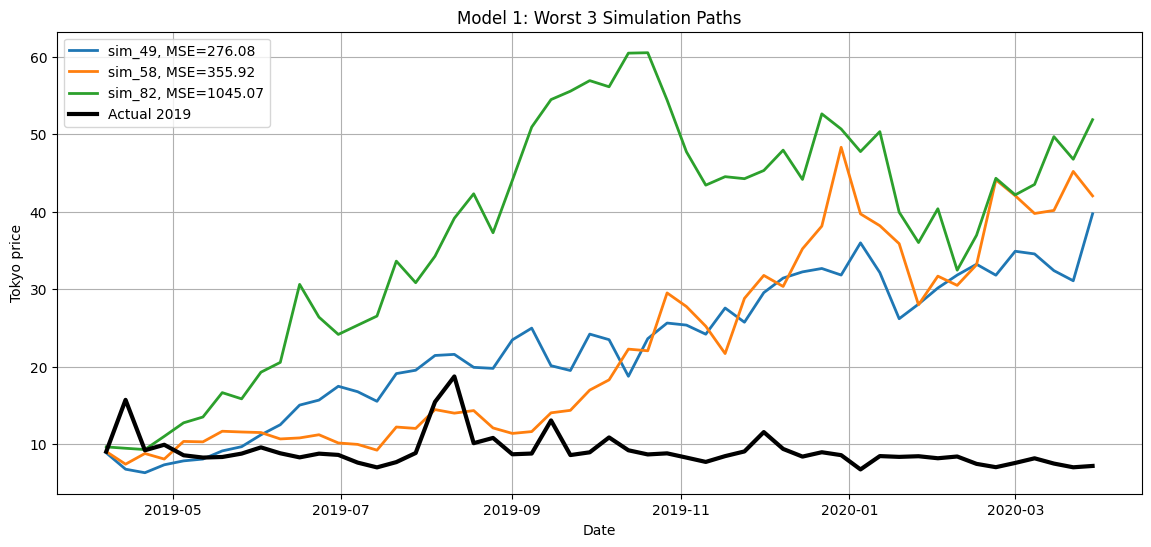

In [15]:
# =============================
# だめだめパス3本
# =============================

plot_selected_paths(
    sims=sims1, test=test, paths=bad_paths, title="Model 1: Worst 3 Simulation Paths"
)

# 真面目に推定する

In [16]:
import statsmodels.api as sm

# =============================
# 説明変数
# =============================

X = train[["log_price_lag1", "temp_centered_sq_lag1"]]

# 切片追加
X = sm.add_constant(X)

# 目的変数
y = train["log_price"]

# =============================
# OLS
# =============================

model = sm.OLS(y, X)

result = model.fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                     80.40
Date:                Wed, 20 May 2026   Prob (F-statistic):           1.29e-21
Time:                        07:01:40   Log-Likelihood:                 82.391
No. Observations:                 104   AIC:                            -158.8
Df Residuals:                     101   BIC:                            -150.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.98

In [17]:
# =============================
# statsmodels OLS の推定値を取得
# =============================

c_hat = result.params["const"]
alpha_hat = result.params["log_price_lag1"]
beta_hat = result.params["temp_centered_sq_lag1"]

sigma_hat = result.resid.std()

print("c     =", c_hat)
print("alpha =", alpha_hat)
print("beta  =", beta_hat)
print("sigma =", sigma_hat)

c     = 0.9840987354963626
alpha = 0.5522970774605569
beta  = 0.0009552270834550812
sigma = 0.11010457014315829


純粋生成でシミュレーション
$$
\hat{y}_t \to \hat{y}_{t+1}
$$

In [18]:
# =============================
# モデル1：切片ありで100本シミュレーション
# =============================


def simulate_model1_ols(test, c, alpha, beta, sigma, n_sim=100, seed=42):
    rng = np.random.default_rng(seed)

    sims = pd.DataFrame(index=test.index)

    for i in range(n_sim):
        log_s = []
        log_prev = test["log_price"].iloc[0]

        for t in range(len(test)):
            x_temp = test["temp_centered_sq_lag1"].iloc[t]
            eps = rng.normal(0, sigma)

            log_new = c + alpha * log_prev + beta * x_temp + eps

            log_s.append(log_new)
            log_prev = log_new

        sims[f"sim_{i + 1}"] = np.exp(log_s)

    return sims


sims1_ols = simulate_model1_ols(
    test=test,
    c=c_hat,
    alpha=alpha_hat,
    beta=beta_hat,
    sigma=sigma_hat,
    n_sim=100,
    seed=42,
)

In [19]:
# =============================
# MSE順位でパスを分類
# =============================

actual = test["tokyo_price"]

mse_by_path_ols = ((sims1_ols.sub(actual, axis=0)) ** 2).mean(axis=0)
mse_sorted_ols = mse_by_path_ols.sort_values()

near_paths_ols = mse_sorted_ols.index[:3]

mid = len(mse_sorted_ols) // 2
middle_paths_ols = mse_sorted_ols.index[mid - 1 : mid + 2]

bad_paths_ols = mse_sorted_ols.index[-3:]

print("Near paths")
print(mse_sorted_ols.loc[near_paths_ols])

print("\nMiddle paths")
print(mse_sorted_ols.loc[middle_paths_ols])

print("\nBad paths")
print(mse_sorted_ols.loc[bad_paths_ols])

Near paths
sim_30    4.461285
sim_13    4.629545
sim_16    4.705089
dtype: float64

Middle paths
sim_17    7.779593
sim_71    7.790573
sim_34    7.844861
dtype: float64

Bad paths
sim_28    10.476759
sim_66    10.549252
sim_50    11.033473
dtype: float64


In [20]:
# =============================
# プロット用関数
# =============================


def plot_selected_paths_ols(sims, test, paths, mse_by_path, title):
    plt.figure(figsize=(14, 6))

    for col in paths:
        plt.plot(
            sims.index,
            sims[col],
            linewidth=2,
            label=f"{col}, MSE={mse_by_path[col]:.2f}",
        )

    plt.plot(
        test.index, test["tokyo_price"], color="black", linewidth=3, label="Actual 2019"
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Tokyo price")
    plt.legend()
    plt.grid(True)
    plt.show()

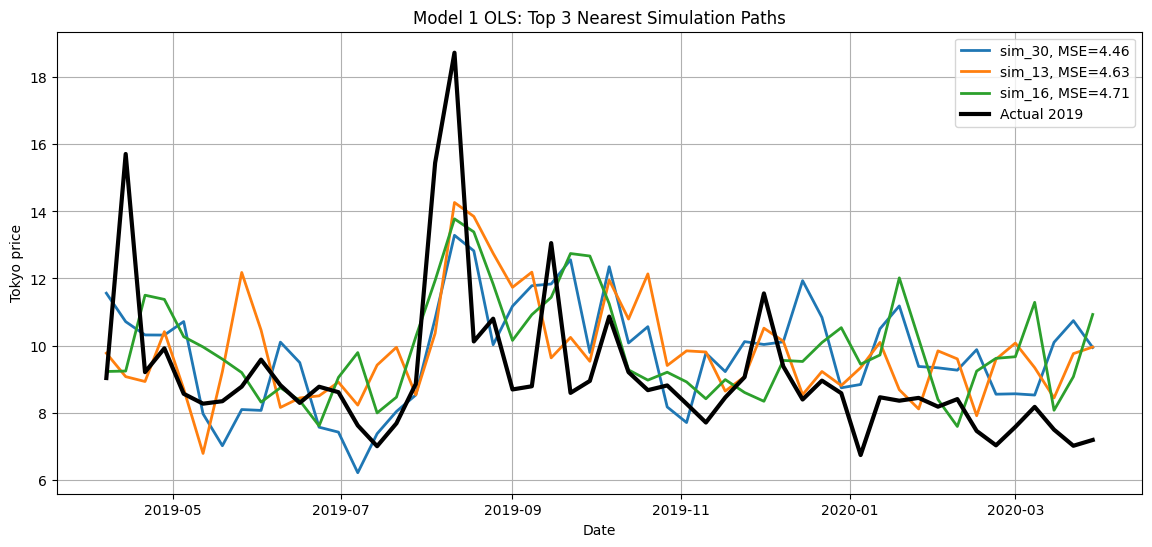

In [21]:
# =============================
# 1. それっぽいパス3本
# =============================

plot_selected_paths_ols(
    sims=sims1_ols,
    test=test,
    paths=near_paths_ols,
    mse_by_path=mse_by_path_ols,
    title="Model 1 OLS: Top 3 Nearest Simulation Paths",
)

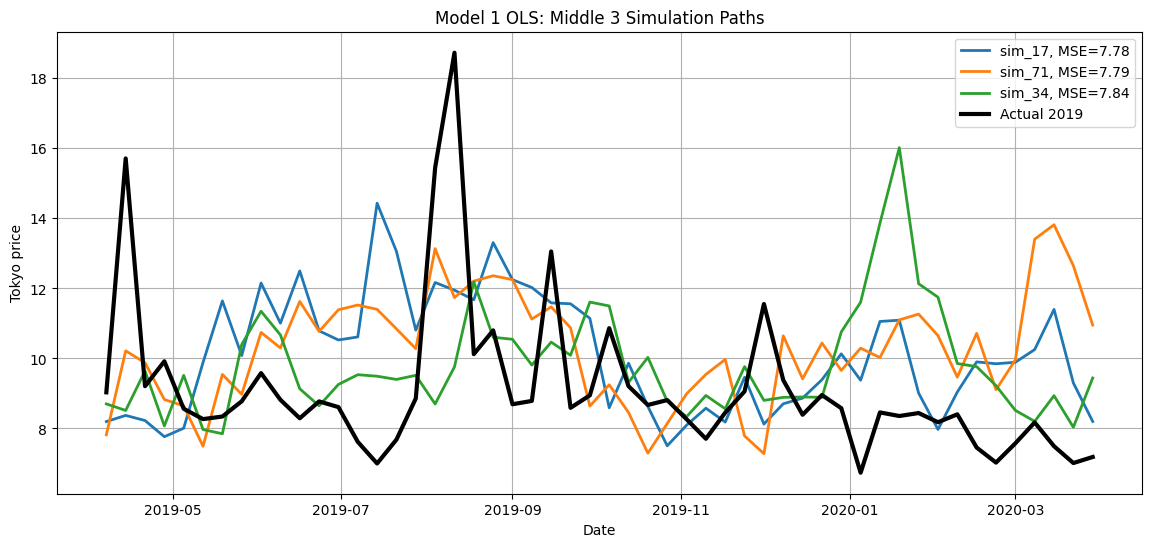

In [22]:
# =============================
# 2. 中間パス3本
# =============================

plot_selected_paths_ols(
    sims=sims1_ols,
    test=test,
    paths=middle_paths_ols,
    mse_by_path=mse_by_path_ols,
    title="Model 1 OLS: Middle 3 Simulation Paths",
)

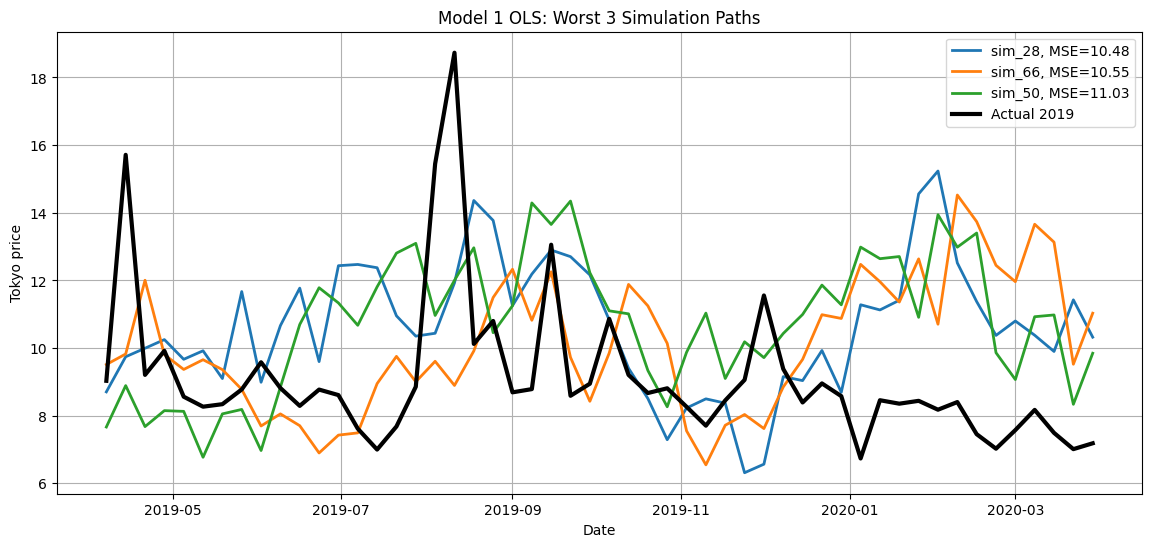

In [23]:
# =============================
# 3. だめだめパス3本
# =============================

plot_selected_paths_ols(
    sims=sims1_ols,
    test=test,
    paths=bad_paths_ols,
    mse_by_path=mse_by_path_ols,
    title="Model 1 OLS: Worst 3 Simulation Paths",
)

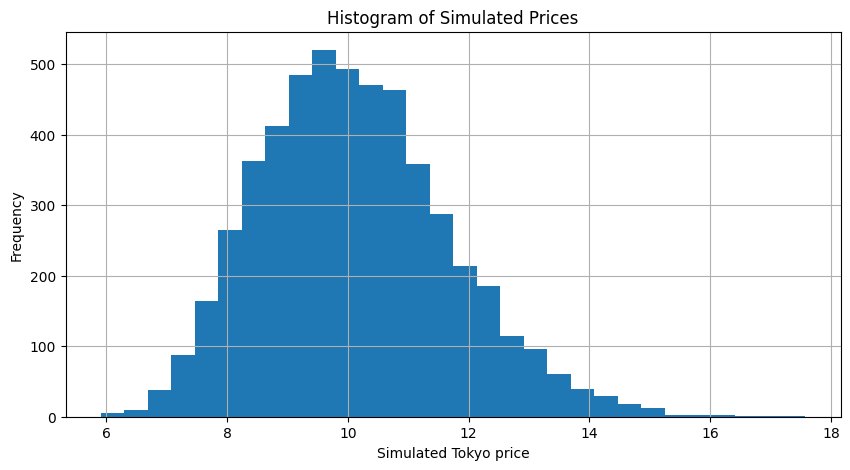

In [28]:
# =============================
# 100本 × 全時点 の価格分布ヒストグラム
# =============================

sim_values = sims1_ols.values.flatten()

plt.figure(figsize=(10, 5))

plt.hist(sim_values, bins=30)

plt.title("Histogram of Simulated Prices")
plt.xlabel("Simulated Tokyo price")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

考察

これは説明変数でスパイク構造を入れられたわけではなく、単に対数正規分布だからそれっぽいシミュレーションができただけに見える

In [29]:
# =============================
# t分布誤差によるシミュレーション
# =============================


def simulate_model1_t_error(test, c, alpha, beta, sigma, nu=5, n_sim=100, seed=42):
    rng = np.random.default_rng(seed)

    sims = pd.DataFrame(index=test.index)

    # t分布の分散を1に標準化する係数
    # Var(t_nu) = nu / (nu - 2)
    scale_adjust = np.sqrt((nu - 2) / nu)

    for i in range(n_sim):
        log_s = []
        log_prev = test["log_price"].iloc[0]

        for t in range(len(test)):
            x_temp = test["temp_centered_sq_lag1"].iloc[t]

            eps = sigma * scale_adjust * rng.standard_t(df=nu)

            log_new = c + alpha * log_prev + beta * x_temp + eps

            log_s.append(log_new)
            log_prev = log_new

        sims[f"sim_{i + 1}"] = np.exp(log_s)

    return sims

In [30]:
# =============================
# シミュレーション実行
# =============================

sims1_t = simulate_model1_t_error(
    test=test,
    c=c_hat,
    alpha=alpha_hat,
    beta=beta_hat,
    sigma=sigma_hat,
    nu=5,
    n_sim=100,
    seed=42,
)

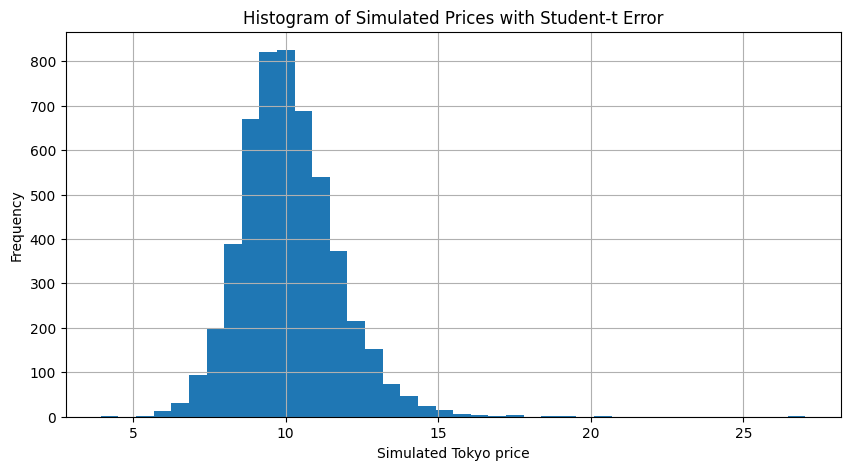

In [31]:
# =============================
# シミュレーション価格ヒストグラム
# =============================

sim_values_t = sims1_t.values.flatten()

plt.figure(figsize=(10, 5))

plt.hist(sim_values_t, bins=40)

plt.title("Histogram of Simulated Prices with Student-t Error")
plt.xlabel("Simulated Tokyo price")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

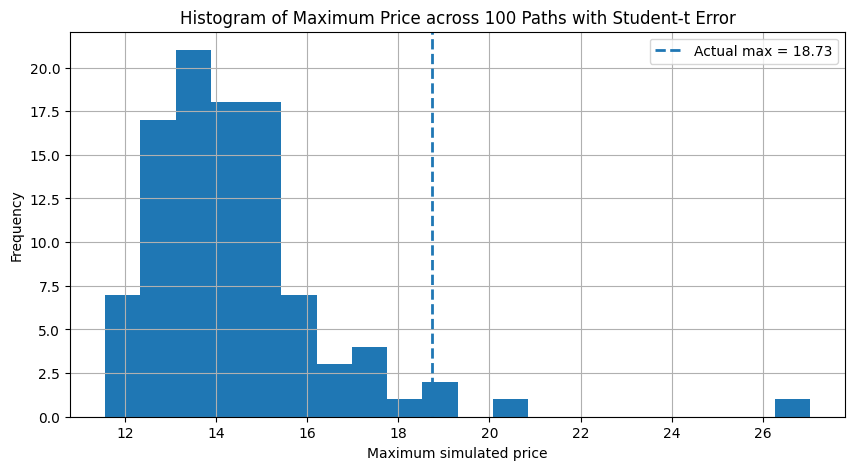

In [32]:
# =============================
# 各シミュレーションパスの最大価格ヒストグラム
# =============================

max_by_path_t = sims1_t.max(axis=0)

plt.figure(figsize=(10, 5))

plt.hist(max_by_path_t, bins=20)

plt.axvline(
    test["tokyo_price"].max(),
    linestyle="--",
    linewidth=2,
    label=f"Actual max = {test['tokyo_price'].max():.2f}",
)

plt.title("Histogram of Maximum Price across 100 Paths with Student-t Error")
plt.xlabel("Maximum simulated price")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

In [41]:
# =============================
# MSE順位でパスを分類
# =============================

actual = test["tokyo_price"]

mse_by_path_t = ((sims1_t.sub(actual, axis=0)) ** 2).mean(axis=0)
mse_sorted_t = mse_by_path_t.sort_values()

near_paths_t = mse_sorted_t.index[:3]

mid = len(mse_sorted_t) // 2
middle_paths_t = mse_sorted_t.index[mid - 1 : mid + 2]

bad_paths_t = mse_sorted_t.index[-3:]

print("Near paths")
print(mse_sorted_t.loc[near_paths_t])

print("\nMiddle paths")
print(mse_sorted_t.loc[middle_paths_t])

print("\nBad paths")
print(mse_sorted_t.loc[bad_paths_t])

Near paths
sim_28    4.552809
sim_48    4.745207
sim_14    4.815472
dtype: float64

Middle paths
sim_33    7.445409
sim_32    7.533546
sim_74    7.558062
dtype: float64

Bad paths
sim_89    10.635079
sim_71    11.744849
sim_43    15.315754
dtype: float64


In [42]:
# =============================
# プロット用関数
# =============================


def plot_selected_paths_t(sims, test, paths, mse_by_path, title):
    plt.figure(figsize=(14, 6))

    for col in paths:
        plt.plot(
            sims.index,
            sims[col],
            linewidth=2,
            label=f"{col}, MSE={mse_by_path[col]:.2f}",
        )

    plt.plot(
        test.index, test["tokyo_price"], color="black", linewidth=3, label="Actual 2019"
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Tokyo price")
    plt.legend()
    plt.grid(True)
    plt.show()

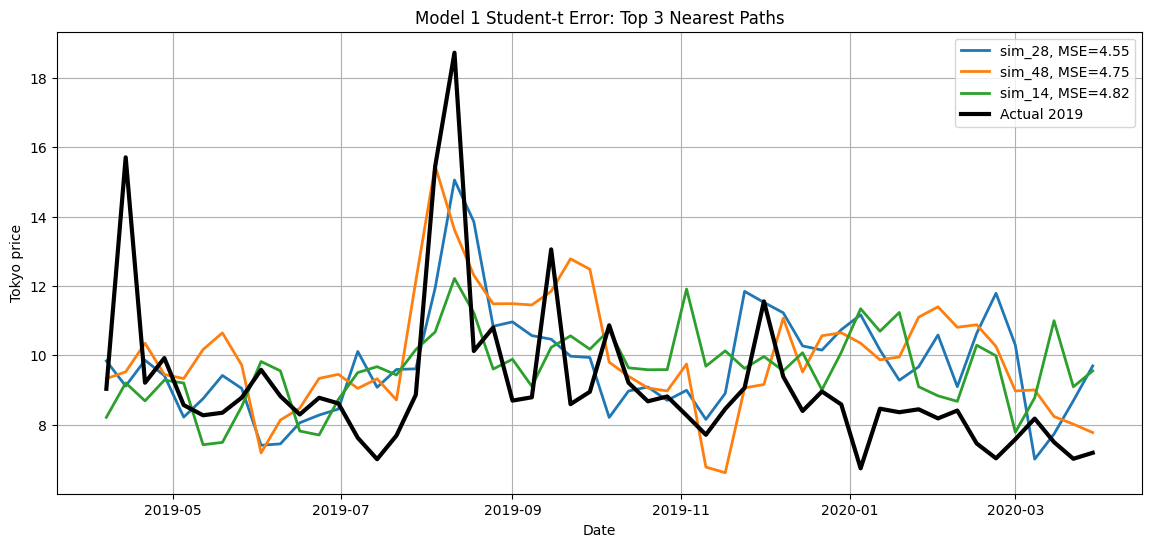

In [43]:
plot_selected_paths_t(
    sims=sims1_t,
    test=test,
    paths=near_paths_t,
    mse_by_path=mse_by_path_t,
    title="Model 1 Student-t Error: Top 3 Nearest Paths",
)

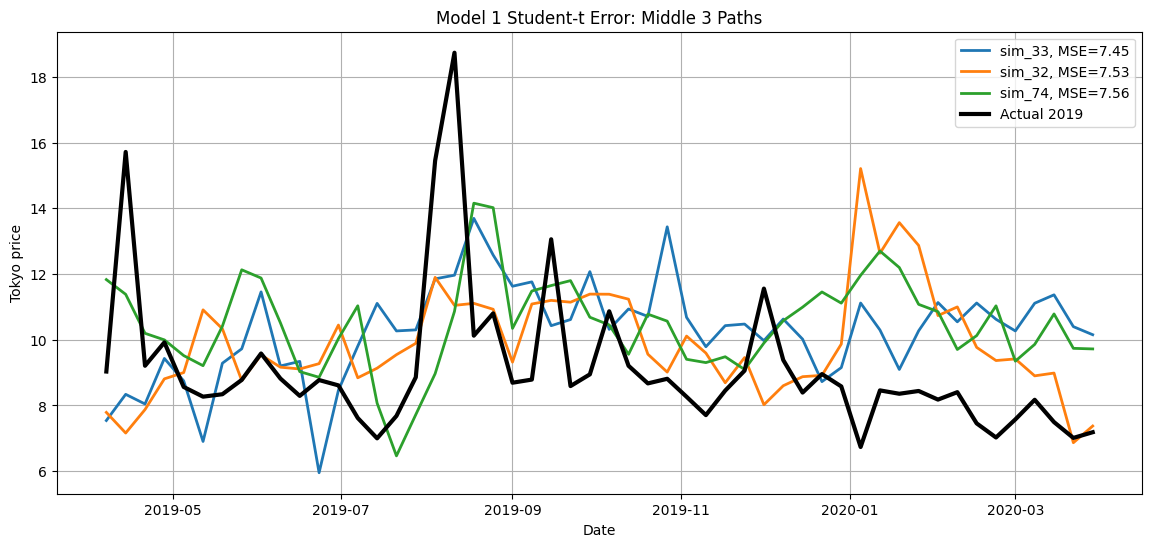

In [44]:
plot_selected_paths_t(
    sims=sims1_t,
    test=test,
    paths=middle_paths_t,
    mse_by_path=mse_by_path_t,
    title="Model 1 Student-t Error: Middle 3 Paths",
)

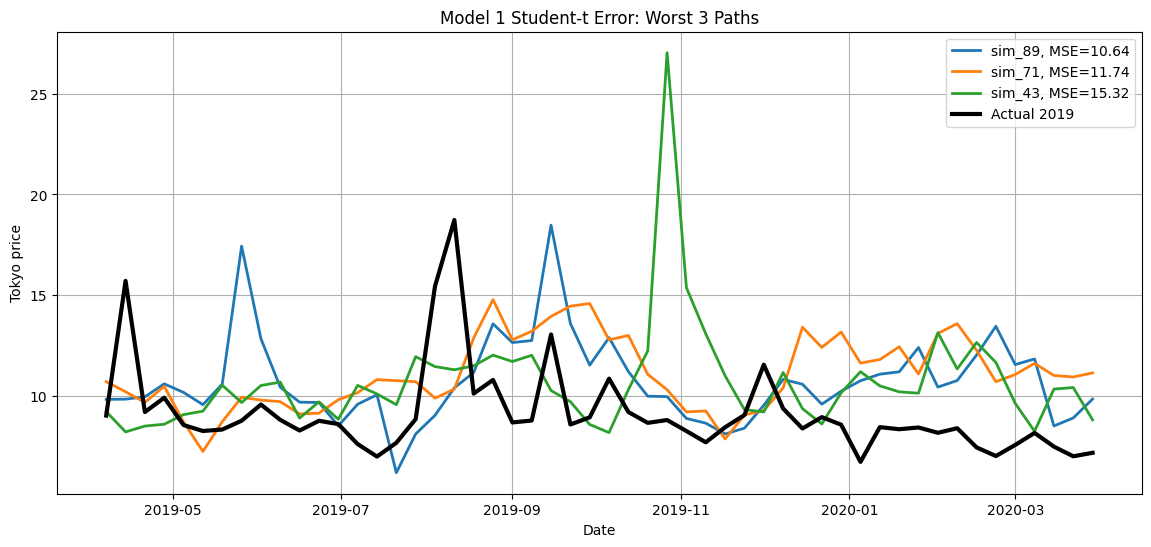

In [45]:
plot_selected_paths_t(
    sims=sims1_t,
    test=test,
    paths=bad_paths_t,
    mse_by_path=mse_by_path_t,
    title="Model 1 Student-t Error: Worst 3 Paths",
)